In [1]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Font size settings for figures
mpl.rcParams.update({
    "font.size": 14,              # base font size
    "axes.titlesize": 16,         # title font
    "axes.labelsize": 14,         # x/y label font
    "xtick.labelsize": 12,        # x-tick labels
    "ytick.labelsize": 12,        # y-tick labels
    "legend.fontsize": 12,        # legend text
    "lines.linewidth": 2,         # line thickness
    "axes.linewidth": 1.2,        # axis border thickness
})

# Function to make annotating data on figures easier
def annotate_final_values(ax, x, y_values, labels, min_sep_frac=0.1):
    """
    Adds annotations at the final time point of each y-series with spacing done in axis-fraction units.

    Parameters:
        ax: matplotlib Axes object
        x: time points (1D array)
        y_values: list of y-arrays
        labels: list of label strings
        min_sep_frac: minimum spacing between annotations in axis fraction (0.03 = 3% of y-axis height)
    """
    final_x = x[-1]
    final_ys = [y[-1] for y in y_values]
    y_min, y_max = ax.get_ylim()

    # Convert y-values to axis-fraction space
    y_fracs = [(y - y_min) / (y_max - y_min) for y in final_ys]

    # Sort and apply minimum spacing in axis-fraction space
    sorted_indices = np.argsort(y_fracs)
    new_frac_positions = {}
    last_frac = None
    for idx in sorted_indices:
        frac = y_fracs[idx]
        if last_frac is None:
            new_frac_positions[idx] = frac
        else:
            new_frac_positions[idx] = max(frac, last_frac + min_sep_frac)
        last_frac = new_frac_positions[idx]

    # Clamp to [0,1] and convert back to data coordinates
    for idx in range(len(y_values)):
        orig_y = final_ys[idx]
        frac_y = min(new_frac_positions[idx], 0.98)  # avoid going out of bounds
        adjusted_y = y_min + frac_y * (y_max - y_min)

        ax.annotate(f"{labels[idx]}\n{orig_y:.0f}",
                    xy=(final_x, orig_y),
                    xytext=(final_x + 1, adjusted_y),
                    textcoords='data',
                    fontsize=8,
                    va='center',
                    ha='left',
                    arrowprops=dict(arrowstyle='->', lw=0.5),
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.5))

# Volume-Adder Neuroblast Growth Rate Scaled to Birth Volume

## Model Purpose

This model tests whether differences in NB birth volume alone can explain the reduced cell counts observed in mudmut NB colonies, under an adder-based cell-cycle control. The underlying hypothesis is:
- Adder control: NBs do not divide at a fixed size; instead, they must add a fixed volume ΔV to their birth volume before division occurs.
- Growth rate effect: Symmetric NB divisions in mudmut colonies produce daughter NBs with much smaller birth volumes than WT NBs. If NB growth rate scales with birth size, these smaller cells will grow more slowly, lengthening their cycles and reducing overall cell counts.

This formulation isolates the growth rate effect from any division-threshold scaling, as division depends only on volume added since birth, not on absolute cell size.


## Model Species
- $N_{\text{NB}}, V_{\text{NB}}$ — Neuroblast (NB) count & total NB volume
- $S_{\text{NB}}$ — Sum of NB birth volumes (bookkeeping variable for adder control)
- $N_{\text{GMC}}, V_{\text{GMC}}$ — GMC count & total GMC volume
- $N_{\text{ImNeuron}}, V_{\text{ImNeuron}}$ — Immature neuron count & volume
- $N_{\text{MatNeuron}}, V_{\text{MatNeuron}}$ — Mature neuron count & volume

## Model Parameters
- $g_{\text{NB,base}}$ — Base NB growth rate at reference birth size
- $g_{\text{GMC}}$ — GMC growth rate
- $k_{\text{Neuron}}$ — Immature neuron → mature neuron maturation rate
- $\text{sym\_frac}$ — Fraction of symmetric NB divisions
- $k_{\text{max,NB}}$ — Maximum NB division rate
- $k_{\text{max,GMC}}$ — Maximum GMC division rate
- $n$ — Adder sharpness exponent in division control
- $\Delta V_{\text{add,NB}}$ — NB adder target (volume to add before division)
- $\Delta V_{\text{add,GMC}}$ — GMC adder target
- $V_{\text{ref}}$ — Reference NB birth volume for growth scaling
- $\alpha_{\text{birth}}$ — Exponent for how NB growth rate scales with birth size

## Average Volumes and Birth Volumes
- Average NB volume: $\bar{V}_{\text{NB}} = V_{\text{NB}} / N_{\text{NB}}$
- Average GMC volume: $\bar{V}_{\text{GMC}} = V_{\text{GMC}} / N_{\text{GMC}}$
- Average NB birth volume: $\bar{B}_{\text{NB}} = S_{\text{NB}} / N_{\text{NB}}$

The added volumes are:
$$
\Delta V_{\text{NB}} = \max\!\big(0, \bar{V}_{\text{NB}} - \bar{B}_{\text{NB}}\big),
\qquad
\Delta V_{\text{GMC}} = \max\!\big(0, \bar{V}_{\text{GMC}}\big)
$$

## Growth Rate Scaling
NB growth rate scales with average birth volume relative to a reference:
$$
g_{\text{NB,eff}} = g_{\text{NB,base}} \cdot \left(\frac{\bar{B}_{\text{NB}}}{V_{\text{ref}}}\right)^{\alpha_{\text{birth}}}
$$
- If $\bar{B}_{\text{NB}} < V_{\text{ref}}$ and $\alpha_{\text{birth}} > 0$, NB growth is slower.

## Division Rates — Adder Logic (saturating power law)

Division readiness depends on **added volume since birth** via a capped power law:
$$
k_{\text{NB}} \;=\; k_{\text{max,NB}} \cdot \min\!\left(1,\;\left(\frac{\Delta V_{\text{NB}}}{\Delta V_{\text{add,NB}}}\right)^{n}\right),
$$
$$
k_{\text{GMC}} \;=\; k_{\text{max,GMC}} \cdot \min\!\left(1,\;\left(\frac{\Delta V_{\text{GMC}}}{\Delta V_{\text{add,GMC}}}\right)^{n}\right).
$$

Where:
- $\Delta V_{\text{NB}} = \max\!\big(0,\,\bar{V}_{\text{NB}} - \bar{B}_{\text{NB}}\big)$ is the NB volume added since birth,
- $\Delta V_{\text{GMC}} = \max\!\big(0,\,\bar{V}_{\text{GMC}}\big)$ (GMCs start with negligible birth volume in this model).

- The exponent $n$ sets sharpness; rates increase as $(\Delta V / \Delta V_{\text{add}})^{n}$ when below target and **saturate at** $k_{\max}$ once $\Delta V \ge \Delta V_{\text{add}}$.

## Partitioning of NB Divisions

Same as in the sizer model:
$$
\text{sym\_divs} = \text{sym\_frac} \cdot k_{\text{NB}} \cdot N_{\text{NB}}, \quad
\text{asym\_divs} = (1 - \text{sym\_frac}) \cdot k_{\text{NB}} \cdot N_{\text{NB}}
$$

## ODEs

**NB Birth-Volume Sum $(S_{\text{NB}})$**
Remove parent’s birth volume at division; add daughters’ birth volumes:
$$
\frac{dS_{\text{NB}}}{dt}
= -k_{\text{NB}} \cdot N_{\text{NB}} \cdot \bar{B}_{\text{NB}}
+ \text{sym\_divs} \cdot \bar{V}_{\text{NB}}
+ \text{asym\_divs} \cdot \big(0.8 \cdot \bar{V}_{\text{NB}}\big)
$$

**Neuroblast Count**
$$
\frac{dN_{\text{NB}}}{dt} = \text{sym\_divs}
$$

**Neuroblast Volume**
$$
\frac{dV_{\text{NB}}}{dt}
= g_{\text{NB,eff}} \cdot N_{\text{NB}}
- 0.2 \cdot \text{asym\_divs} \cdot \bar{V}_{\text{NB}}
$$

**GMC Count**
$$
\frac{dN_{\text{GMC}}}{dt}
= \text{asym\_divs}
- k_{\text{GMC}} \cdot N_{\text{GMC}}
$$

**GMC Volume**
$$
\frac{dV_{\text{GMC}}}{dt}
= g_{\text{GMC}} \cdot N_{\text{GMC}}
+ 0.2 \cdot \text{asym\_divs} \cdot \bar{V}_{\text{NB}}
- k_{\text{GMC}} \cdot N_{\text{GMC}} \cdot \bar{V}_{\text{GMC}}
$$

**Immature Neuron Count**
$$
\frac{dN_{\text{ImNeuron}}}{dt}
= 2 \cdot k_{\text{GMC}} \cdot N_{\text{GMC}}
- k_{\text{Neuron}} \cdot N_{\text{ImNeuron}}
$$

**Immature Neuron Volume**
$$
\frac{dV_{\text{ImNeuron}}}{dt}
= k_{\text{GMC}} \cdot N_{\text{GMC}} \cdot \bar{V}_{\text{GMC}}
- k_{\text{Neuron}} \cdot N_{\text{ImNeuron}} \cdot \bar{V}_{\text{ImNeuron}}
$$

**Mature Neuron Count**
$$
\frac{dN_{\text{MatNeuron}}}{dt}
= k_{\text{Neuron}} \cdot N_{\text{ImNeuron}}
$$

**Mature Neuron Volume**
$$
\frac{dV_{\text{MatNeuron}}}{dt}
= k_{\text{Neuron}} \cdot N_{\text{ImNeuron}} \cdot \bar{V}_{\text{ImNeuron}}
$$

In [2]:
def neuroblast_model_volume_saturating_powerlaw_birth_scaled_growth(t, y, params):
    """
    Neuroblast model with saturating power-law division dynamics
    and NB growth rate scaled by average NB birth volume.

    State vector:
        y = [N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat, S_NB]
            N_*  : cell counts
            V_*  : total volumes
            S_NB : sum of NB birth volumes (bookkeeping for division thresholds)

    Parameters (list/tuple in this order):
        g_NB_base    : base NB growth rate (volume/hour)
        g_GMC        : GMC growth rate (volume/hour)
        k_Neuron     : maturation rate (1/hour)
        sym_frac     : fraction of NB divisions that are symmetric [0..1]
        k_max_NB     : max NB division rate (1/hour)
        k_max_GMC    : max GMC division rate (1/hour)
        n            : exponent for saturating power-law division dynamics
        dV_add_NB    : NB characteristic added-volume scale (reference volume increment)
        dV_add_GMC   : GMC characteristic added-volume scale
        V_ref        : reference birth volume for NB growth scaling
        alpha_birth  : exponent for NB birth-volume growth scaling
                    (>0 reduces growth when birth volume is smaller than V_ref)

    Notes:
    - NB effective growth rate:
            g_NB_eff = g_NB_base * (Bavg_NB / V_ref)^alpha_birth
    - Division rates:
            k = k_max * min(1, (ΔV / ΔV_add)^n)
        where ΔV is added volume since birth. This produces a
        saturating power-law increase with ΔV, capped at k_max.
    - Bookkeeping:
            S_NB tracks NB birth volumes so that ΔV_NB can be
            computed as Vavg_NB - Bavg_NB.
    """
    (N_NB, V_NB,
     N_GMC, V_GMC,
     N_Im,  V_Im,
     N_Mat, V_Mat,
     S_NB) = y

    (g_NB_base, g_GMC,
     k_Neuron,
     sym_frac,
     k_max_NB, k_max_GMC,
     n,
     dV_add_NB, dV_add_GMC,
     V_ref, alpha_birth) = params

    # --- Averages with guards ---
    Vavg_NB = V_NB / N_NB if N_NB > 0 else 0.0
    Vavg_GMC = V_GMC / N_GMC if N_GMC > 0 else 0.0
    Vavg_Im = V_Im / N_Im if N_Im > 0 else 0.0

    Bavg_NB = S_NB / N_NB if N_NB > 0 else 0.0          # average NB birth volume

    # --- NB growth scaling by average birth volume ---
    if V_ref > 0 and Bavg_NB > 0:
        scale_birth = (Bavg_NB / V_ref) ** alpha_birth
    else:
        scale_birth = 0.0 if alpha_birth > 0 else 1.0  # if no NBs and alpha>0, growth effectively off
    g_NB_eff = g_NB_base * scale_birth

    # --- Adder logic: added volume since birth ---
    dV_NB = max(0.0, Vavg_NB - Bavg_NB)
    dV_GMC = max(0.0, Vavg_GMC - 0.0)

    # --- Division rates (saturating power in added volume; capped at k_max) ---
    k_NB = 0.0
    k_GMC = 0.0
    if N_NB > 0 and dV_add_NB > 0:
        core_NB = (dV_NB / dV_add_NB)**n if dV_NB > 0 else 0.0
        core_NB = 1.0 if core_NB >= 1.0 else core_NB
        k_NB = k_max_NB * core_NB

    if N_GMC > 0 and dV_add_GMC > 0:
        core_GMC = (dV_GMC / dV_add_GMC)**n if dV_GMC > 0 else 0.0
        core_GMC = 1.0 if core_GMC >= 1.0 else core_GMC
        k_GMC = k_max_GMC * core_GMC

    # --- Division fluxes ---
    sym_divs  = sym_frac * k_NB * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB * N_NB

    # --- Neuroblasts ---
    dN_NB = sym_divs
    dV_NB = (
        g_NB_eff * N_NB
        - k_NB * N_NB * Vavg_NB       # remove parent NB volumes on any NB division
        + sym_divs * Vavg_NB          # add birth volume of two NB daughters (net +Vavg_NB)
        + asym_divs * 0.8 * Vavg_NB   # add birth volume of NB daughter in asymmetric division
    )
    # Birth-volume bookkeeping for NB (remove parents' birth volume, add daughters')
    dS_NB = (
        - k_NB * N_NB * Bavg_NB              # remove parents' birth volume
        + sym_divs * Vavg_NB                 # add two NB daughters' birth volumes: net +Vavg_NB
        + asym_divs * (0.8 * Vavg_NB)        # add NB daughter (0.8 * Vavg_NB) in asymmetric division
    )

    # --- GMCs ---
    dN_GMC = asym_divs - k_GMC * N_GMC
    dV_GMC = (
        g_GMC * N_GMC
        + asym_divs * 0.2 * Vavg_NB
        - k_GMC * N_GMC * Vavg_GMC
    )

    # --- Neurons ---
    dN_Im  = 2.0 * k_GMC * N_GMC - k_Neuron * N_Im
    dV_Im  = k_GMC * N_GMC * Vavg_GMC - k_Neuron * N_Im * Vavg_Im

    dN_Mat = k_Neuron * N_Im
    dV_Mat = k_Neuron * N_Im * Vavg_Im

    return [
        dN_NB, dV_NB,
        dN_GMC, dV_GMC,
        dN_Im,  dV_Im,
        dN_Mat, dV_Mat,
        dS_NB
    ]

WT model

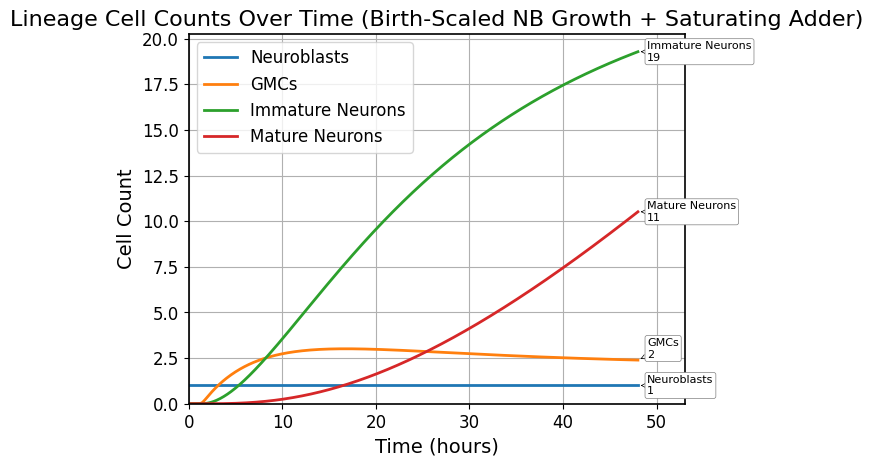

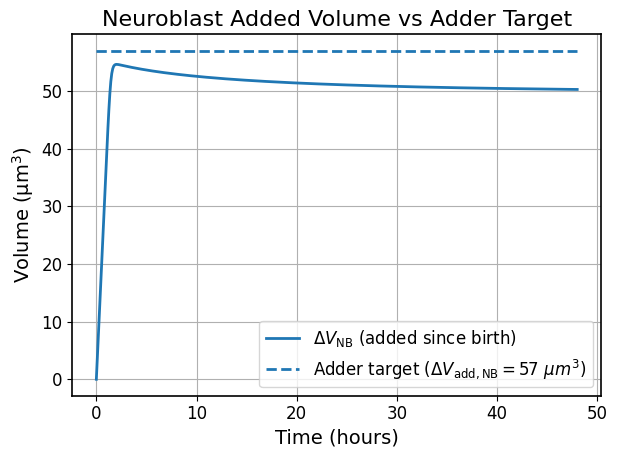

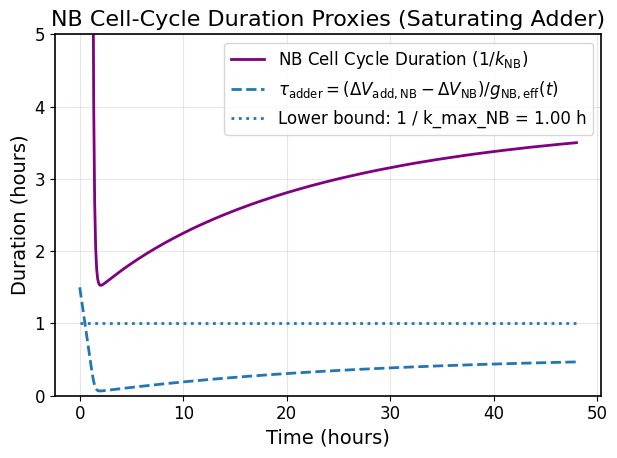

In [ ]:
# --- WT params (birth-scaled NB growth + saturating adder division) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

g_NB_base = nb_vol * 0.2 / 1.5              # NB base growth rate (volume/hr)
g_GMC     = (nb_vol * 1.2 * 0.2) / 9        # GMC growth rate (volume/hr)

k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)
n         = 10                               # Exponent in the saturating adder

sym_frac  = 0.0                             # Fraction of NB divisions that are symmetric
k_Neuron  = 1.0 / 48.0                      # Immature neuron maturation rate (1/hr)

# Adder targets (volumes to add since birth to reach k_max)
dV_add_NB  = 0.20 * nb_vol                  # NB must add ~20% of reference NB volume
dV_add_GMC = 0.24 * nb_vol                  # GMC must add ~24% of reference NB volume

# NB growth rate scaling by birth size
V_ref        = nb_vol                        # Reference NB birth volume
alpha_birth  = 3.0                           # >0 → smaller-at-birth NBs grow more slowly

# Parameter order for this model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  k_max_NB, k_max_GMC, n,
#  dV_add_NB, dV_add_GMC,
#  V_ref, alpha_birth)
params_adder_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    k_max_NB, k_max_GMC,
    n,
    dV_add_NB, dV_add_GMC,
    V_ref, alpha_birth
]

# Initial conditions
# y = [N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat, S_NB]
# Start with one NB whose birth volume = nb_vol, so S_NB = nb_vol.
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0, nb_vol]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_adder = solve_ivp(
    neuroblast_model_volume_saturating_powerlaw_birth_scaled_growth,
    t_span, y0, t_eval=t_eval, args=(params_adder_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_adder.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_adder.t, y, label=label)

ax.set_xlim(0, sol_adder.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_adder.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Birth-Scaled NB Growth + Saturating Adder)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB added volume (ΔV) vs adder target ==========
Vavg_NB = np.divide(sol_adder.y[1], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[1]),
                    where=sol_adder.y[0] > 0)
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[8]),
                    where=sol_adder.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

fig, ax = plt.subplots()
ax.plot(sol_adder.t, dV_NB_series, label=r"$\Delta V_{\mathrm{NB}}$ (added since birth)", linewidth=2)
ax.hlines(dV_add_NB, sol_adder.t[0], sol_adder.t[-1], linestyles="--",
          label=rf"Adder target ($\Delta V_{{\mathrm{{add,NB}}}}={dV_add_NB:.0f}\ \mu m^3$)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"Volume (µm$^3$)")
ax.set_title("Neuroblast Added Volume vs Adder Target")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration proxies (robust) ==========

# Recompute the series need
Vavg_NB = np.divide(sol_adder.y[1], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[1]),
                    where=sol_adder.y[0] > 0)
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[8]),
                    where=sol_adder.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

# Birth-scaled NB growth rate g_NB_eff(t) for τ_adder proxy
g_NB_eff_series = g_NB_base * np.where(
    V_ref > 0,
    np.power(np.divide(Bavg_NB, V_ref,
                       out=np.zeros_like(Bavg_NB), where=V_ref > 0), alpha_birth),
    1.0
)

# k_NB(t) = k_max_NB * min(1, (ΔV_NB / dV_add_NB)^n)
with np.errstate(divide='ignore', invalid='ignore'):
    core = np.where(dV_add_NB > 0, (dV_NB_series / dV_add_NB) ** n, 0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = k_max_NB * core

# ---- Robust masking to avoid the initial spike and divide-by-zero ----
eps_frac = 1e-4   # mask very-early phase: ΔV < eps_frac * ΔV_add
eps_k    = 1e-9   # numerical floor for k to avoid 1/0

valid = (dV_NB_series >= (eps_frac * dV_add_NB)) & (k_NB_series > eps_k)

ccd_hazard = np.full_like(k_NB_series, np.nan, dtype=float)
ccd_hazard[valid] = 1.0 / k_NB_series[valid]

# τ_adder proxy = remaining adder / current growth rate
# τ_adder = max(0, ΔV_add - ΔV) / g_NB_eff, masked when g_NB_eff is tiny
tau_adder = np.full_like(dV_NB_series, np.nan, dtype=float)
mask_g = g_NB_eff_series > eps_k
tau_adder[mask_g] = np.maximum(0.0, dV_add_NB - dV_NB_series[mask_g]) / g_NB_eff_series[mask_g]

fig, ax = plt.subplots()
ax.plot(sol_adder.t, ccd_hazard, color="purple",
        label=r"NB Cell Cycle Duration ($1/k_{\mathrm{NB}}$)", linewidth=2)
ax.plot(sol_adder.t, tau_adder, "--",
       label=r"$\tau_{\mathrm{adder}} = (\Delta V_{\mathrm{add,NB}}-\Delta V_{\mathrm{NB}})/g_{\mathrm{NB,eff}}(t)$")

ax.hlines(1.0 / k_max_NB, sol_adder.t[0], sol_adder.t[-1],
          linestyles=":", label=f"Lower bound: 1 / k_max_NB = {1.0/k_max_NB:.2f} h")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_ylim(0, 5)
ax.set_title("NB Cell-Cycle Duration Proxies (Saturating Adder)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

mudmut Simulation

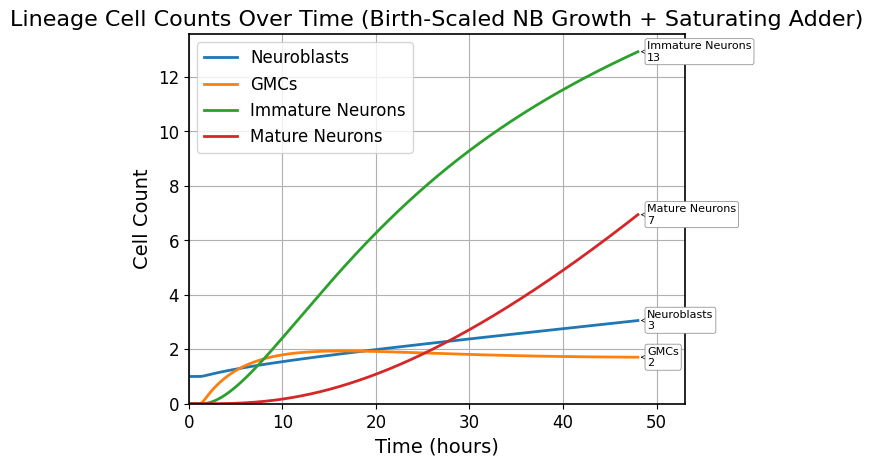

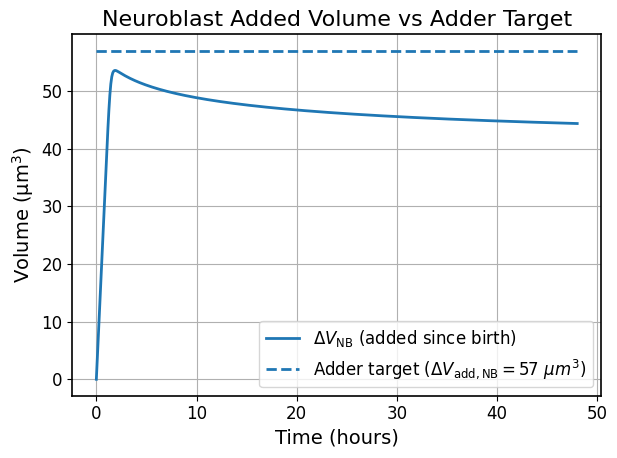

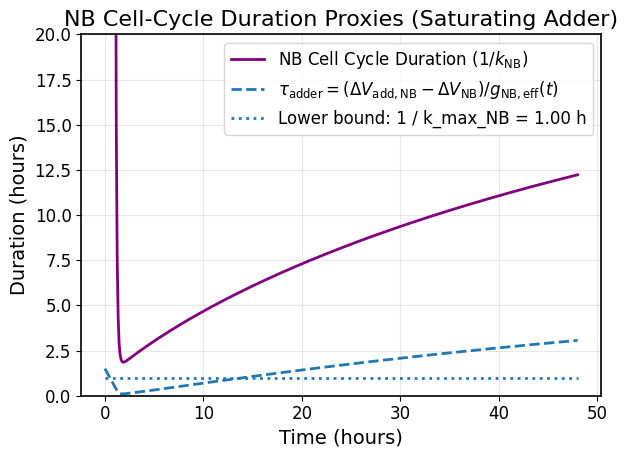

In [ ]:
# --- WT params (birth-scaled NB growth + saturating adder division) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

g_NB_base = nb_vol * 0.2 / 1.5              # NB base growth rate (volume/hr)
g_GMC     = (nb_vol * 1.2 * 0.2) / 9        # GMC growth rate (volume/hr)

k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)
n         = 10                               # Exponent in the saturating adder

sym_frac  = 0.15                            # Fraction of NB divisions that are symmetric
k_Neuron  = 1.0 / 48.0                      # Immature neuron maturation rate (1/hr)

# Adder targets (volumes to add since birth to reach k_max)
dV_add_NB  = 0.20 * nb_vol                  # NB must add ~20% of reference NB volume
dV_add_GMC = 0.24 * nb_vol                  # GMC must add ~24% of reference NB volume

# NB growth rate scaling by birth size
V_ref        = nb_vol                        # Reference NB birth volume
alpha_birth  = 3.0                           # >0 → smaller-at-birth NBs grow more slowly

# Parameter order for this model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  k_max_NB, k_max_GMC, n,
#  dV_add_NB, dV_add_GMC,
#  V_ref, alpha_birth)
params_adder_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    k_max_NB, k_max_GMC,
    n,
    dV_add_NB, dV_add_GMC,
    V_ref, alpha_birth
]

# Initial conditions
# y = [N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat, S_NB]
# Start with one NB whose birth volume = nb_vol, so S_NB = nb_vol.
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0, nb_vol]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_adder = solve_ivp(
    neuroblast_model_volume_saturating_powerlaw_birth_scaled_growth,
    t_span, y0, t_eval=t_eval, args=(params_adder_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_adder.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_adder.t, y, label=label)

ax.set_xlim(0, sol_adder.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_adder.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Birth-Scaled NB Growth + Saturating Adder)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB added volume (ΔV) vs adder target ==========
Vavg_NB = np.divide(sol_adder.y[1], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[1]),
                    where=sol_adder.y[0] > 0)
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[8]),
                    where=sol_adder.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

fig, ax = plt.subplots()
ax.plot(sol_adder.t, dV_NB_series, label=r"$\Delta V_{\mathrm{NB}}$ (added since birth)", linewidth=2)
ax.hlines(dV_add_NB, sol_adder.t[0], sol_adder.t[-1], linestyles="--",
          label=rf"Adder target ($\Delta V_{{\mathrm{{add,NB}}}}={dV_add_NB:.0f}\ \mu m^3$)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"Volume (µm$^3$)")
ax.set_title("Neuroblast Added Volume vs Adder Target")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration proxies (robust) ==========

# Recompute the series need
Vavg_NB = np.divide(sol_adder.y[1], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[1]),
                    where=sol_adder.y[0] > 0)
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0],
                    out=np.zeros_like(sol_adder.y[8]),
                    where=sol_adder.y[0] > 0)
dV_NB_series = np.maximum(0.0, Vavg_NB - Bavg_NB)

# Birth-scaled NB growth rate g_NB_eff(t) for τ_adder proxy
g_NB_eff_series = g_NB_base * np.where(
    V_ref > 0,
    np.power(np.divide(Bavg_NB, V_ref,
                       out=np.zeros_like(Bavg_NB), where=V_ref > 0), alpha_birth),
    1.0
)

# k_NB(t) = k_max_NB * min(1, (ΔV_NB / dV_add_NB)^n)
with np.errstate(divide='ignore', invalid='ignore'):
    core = np.where(dV_add_NB > 0, (dV_NB_series / dV_add_NB) ** n, 0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = k_max_NB * core

# ---- Robust masking to avoid the initial spike and divide-by-zero ----
eps_frac = 1e-4   # mask very-early phase: ΔV < eps_frac * ΔV_add
eps_k    = 1e-9   # numerical floor for k to avoid 1/0

valid = (dV_NB_series >= (eps_frac * dV_add_NB)) & (k_NB_series > eps_k)

ccd_hazard = np.full_like(k_NB_series, np.nan, dtype=float)
ccd_hazard[valid] = 1.0 / k_NB_series[valid]

# τ_adder proxy = remaining adder / current growth rate
# τ_adder = max(0, ΔV_add - ΔV) / g_NB_eff, masked when g_NB_eff is tiny
tau_adder = np.full_like(dV_NB_series, np.nan, dtype=float)
mask_g = g_NB_eff_series > eps_k
tau_adder[mask_g] = np.maximum(0.0, dV_add_NB - dV_NB_series[mask_g]) / g_NB_eff_series[mask_g]

fig, ax = plt.subplots()
ax.plot(sol_adder.t, ccd_hazard, color="purple",
        label=r"NB Cell Cycle Duration ($1/k_{\mathrm{NB}}$)", linewidth=2)
ax.plot(sol_adder.t, tau_adder, "--",
       label=r"$\tau_{\mathrm{adder}} = (\Delta V_{\mathrm{add,NB}}-\Delta V_{\mathrm{NB}})/g_{\mathrm{NB,eff}}(t)$")

ax.hlines(1.0 / k_max_NB, sol_adder.t[0], sol_adder.t[-1],
          linestyles=":", label=f"Lower bound: 1 / k_max_NB = {1.0/k_max_NB:.2f} h")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_ylim(0, 20)
ax.set_title("NB Cell-Cycle Duration Proxies (Saturating Adder)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion:
- Even with a very high n (exponent in the saturating adder, so the NB division rate is very low until the added volume is close to the adder target), the added volume since birth drifts downward over time. This occurs because each division resets the birth volume reference, and when growth is scaled by birth size, smaller-than-reference birth volumes lead to systematically reduced added volumes.
- This drift is an emergent property of the coupling between the adder reset and the birth-volume–scaled growth
- When alpha_birth $ \geq 3 $, mudmut lineages have fewer cells than WT lineages. However, in those conditions WT lineages also have fewer cells than expected overall.
- When alpha_birth $ < 3 $, mudmut lineages have more cells than WT lineages.